# Определение возраста покупателей по фотографии

Сетевой супермаркет внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы и контролировать добросовестность кассиров при продаже алкоголя. Строится модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.

## Исследовательский анализ данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator 

In [2]:
datagen = ImageDataGenerator()

datagen_flow = datagen.flow_from_dataframe(
    pd.read_csv('/datasets/faces/labels.csv'),
    '/datasets/faces/final_files',
    x_col='file_name',
    y_col='real_age',
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    seed=321) 

features, target = next(datagen_flow)

Found 7591 validated image filenames.


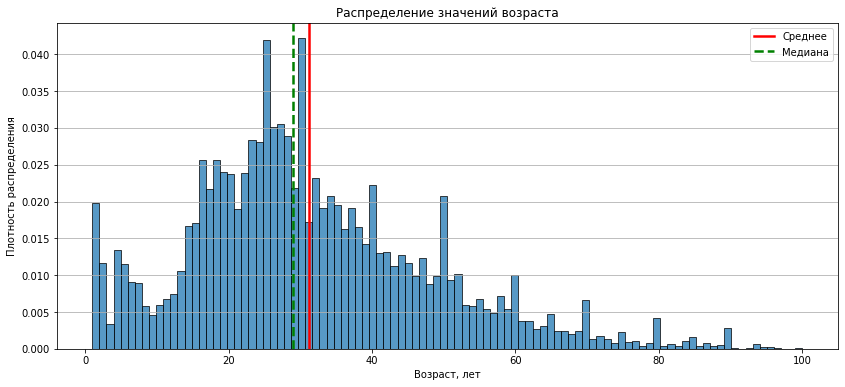

In [6]:
df_labels = pd.read_csv('/datasets/faces/labels.csv')

plt.figure(figsize = (14, 6))
sns.histplot(df_labels['real_age'], bins=100, stat='density', common_norm=False)
plt.axvline(df_labels['real_age'].mean(), c='red', ls='-', lw=2.5, label='Среднее')
plt.axvline(df_labels['real_age'].median(), c='green', ls='--', lw=2.5, label='Медиана')
plt.title(f'Распределение значений возраста')
plt.xlabel('Возраст, лет')
plt.ylabel('Плотность распределения')
plt.grid(axis='y')
plt.legend()
plt.show()

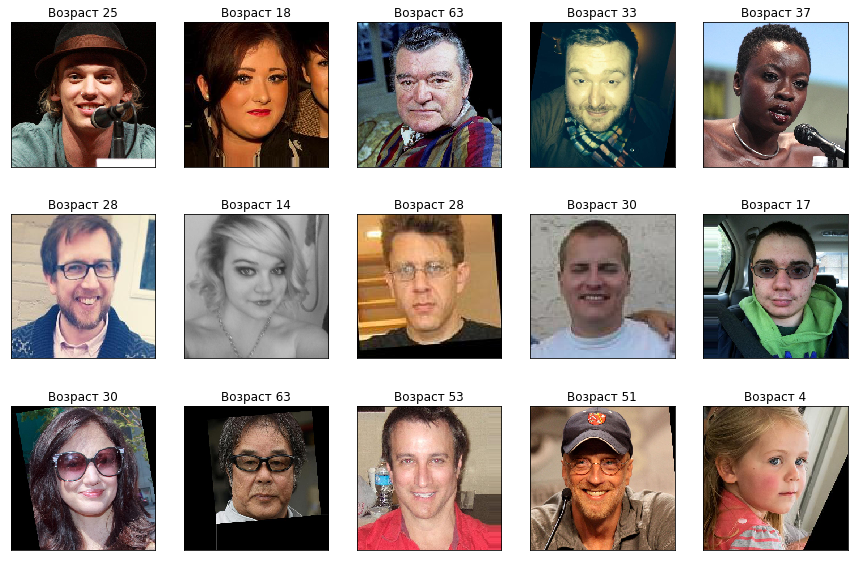

In [4]:
fig, axes = plt.subplots(ncols=5,nrows=3, sharex=True, sharey=True, figsize=(15,10))

for i, ax in enumerate(axes.flat):
    ax.imshow(features[i]/255, interpolation='none')
    ax.set(title='Возраст '+ str(target[i]))
    plt.xticks([])
    plt.yticks([])
    
plt.show()

В данных содержится 7591 фото.

Распределение по возрасту показывает, что в основном присутствуют фото среднего возраста - от 18 до 40 и детей в возрасте пары лет. В возрасте за 70 фото мало, возможно для данной категории модель обучится хуже.

На самих фото могут быть не только лица, но и другие предметы (микрофоны, очки, кепки). Некоторые фото уже имеют небольшой поворот так, чтобы само лицо принимало более вертикальное положение, значит применять rotation_range не будет необходимости.

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.optimizers import Adam

import numpy as np
import pandas as pd



def load_train(path):
    train_datagen = ImageDataGenerator(validation_split=0.25,
                                       rescale=1./255,
                                       horizontal_flip=True,
                                       vertical_flip=True)
    
    train_datagen_flow = train_datagen.flow_from_dataframe(
        pd.read_csv(path + 'labels.csv'),
        path + 'final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=321)
    
    return train_datagen_flow

def load_test(path):
    test_datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    
    test_datagen_flow = test_datagen.flow_from_dataframe(
        pd.read_csv(path + 'labels.csv'),
        path + 'final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=321)

    return test_datagen_flow

def create_model(input_shape):
    
    backbone = ResNet50(input_shape=input_shape,
                        weights='imagenet',
                        include_top=False)
#    backbone.trainable = False
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(1, activation='relu'))
    
    optimizer = Adam(learning_rate=0.0001)
    model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])
    
    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=30, steps_per_epoch=None, validation_steps=None):
    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        batch_size=batch_size,
        validation_steps=validation_steps,
        verbose=2
    )
    return model

```

```

Using TensorFlow backend.
Found 5694 validated image filenames.
Found 1897 validated image filenames.
2025-10-20 09:37:34.927942: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 AVX512F FMA
2025-10-20 09:37:34.956614: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2099990000 Hz
2025-10-20 09:37:34.958489: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x43eacf0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-10-20 09:37:34.958520: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2025-10-20 09:37:35.183768: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5502850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-20 09:37:35.183808: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2025-10-20 09:37:35.185885: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1555] Found device 0 with properties: 
pciBusID: 0000:8b:00.0 name: Tesla V100-SXM2-32GB computeCapability: 7.0
coreClock: 1.53GHz coreCount: 80 deviceMemorySize: 31.75GiB deviceMemoryBandwidth: 836.37GiB/s

Train for 178 steps, validate for 60 steps
Epoch 1/30
2025-10-20 09:37:52.980988: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2025-10-20 09:37:54.073546: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
178/178 - 66s - loss: 248.4712 - mae: 11.4440 - val_loss: 643.3960 - val_mae: 20.3570
Epoch 2/30
178/178 - 38s - loss: 101.9447 - mae: 7.6810 - val_loss: 675.7934 - val_mae: 21.0265
Epoch 3/30
178/178 - 39s - loss: 74.9889 - mae: 6.5686 - val_loss: 418.8242 - val_mae: 15.5281
Epoch 4/30
178/178 - 39s - loss: 63.6504 - mae: 6.0099 - val_loss: 129.0260 - val_mae: 8.7454
Epoch 5/30
178/178 - 38s - loss: 48.9535 - mae: 5.3317 - val_loss: 90.4982 - val_mae: 7.0463
Epoch 6/30
178/178 - 38s - loss: 41.5794 - mae: 4.8788 - val_loss: 82.7896 - val_mae: 7.1123
Epoch 7/30
178/178 - 38s - loss: 34.8559 - mae: 4.4555 - val_loss: 70.4982 - val_mae: 6.2857
Epoch 8/30
178/178 - 38s - loss: 28.2139 - mae: 4.0678 - val_loss: 83.0620 - val_mae: 6.7615
Epoch 9/30
178/178 - 38s - loss: 24.6580 - mae: 3.7750 - val_loss: 78.6718 - val_mae: 6.5623
Epoch 10/30
178/178 - 38s - loss: 22.7976 - mae: 3.5953 - val_loss: 69.3273 - val_mae: 6.3081
Epoch 11/30
178/178 - 38s - loss: 20.7602 - mae: 3.4560 - val_loss: 68.8779 - val_mae: 6.2644
Epoch 12/30
178/178 - 39s - loss: 16.8564 - mae: 3.1192 - val_loss: 72.4085 - val_mae: 6.4222
Epoch 13/30
178/178 - 38s - loss: 15.5673 - mae: 2.9913 - val_loss: 71.6474 - val_mae: 6.2757
Epoch 14/30
178/178 - 38s - loss: 16.0622 - mae: 3.0347 - val_loss: 77.8472 - val_mae: 6.5987
Epoch 15/30
178/178 - 38s - loss: 14.8958 - mae: 2.9324 - val_loss: 73.6531 - val_mae: 6.5091
Epoch 16/30
178/178 - 38s - loss: 13.9350 - mae: 2.7806 - val_loss: 71.3772 - val_mae: 6.2658
Epoch 17/30
178/178 - 39s - loss: 12.5653 - mae: 2.6784 - val_loss: 65.7085 - val_mae: 6.0373
Epoch 18/30
178/178 - 38s - loss: 11.6650 - mae: 2.5687 - val_loss: 63.7526 - val_mae: 5.9846
Epoch 19/30
178/178 - 38s - loss: 11.2976 - mae: 2.5373 - val_loss: 68.3474 - val_mae: 6.3016
Epoch 20/30
178/178 - 38s - loss: 10.3738 - mae: 2.4242 - val_loss: 74.8263 - val_mae: 6.5234
Epoch 21/30
178/178 - 38s - loss: 11.1066 - mae: 2.4989 - val_loss: 68.1972 - val_mae: 6.3832
Epoch 22/30
178/178 - 39s - loss: 10.0185 - mae: 2.3824 - val_loss: 65.6709 - val_mae: 6.0442
Epoch 23/30
178/178 - 38s - loss: 9.4923 - mae: 2.3260 - val_loss: 64.3923 - val_mae: 5.9317
Epoch 24/30
178/178 - 38s - loss: 10.2216 - mae: 2.4157 - val_loss: 65.4199 - val_mae: 5.9950
Epoch 25/30
178/178 - 38s - loss: 9.4029 - mae: 2.2930 - val_loss: 69.6119 - val_mae: 6.1909
Epoch 26/30
178/178 - 38s - loss: 9.9255 - mae: 2.3757 - val_loss: 80.8085 - val_mae: 6.7876
Epoch 27/30
178/178 - 38s - loss: 10.0775 - mae: 2.3938 - val_loss: 63.4334 - val_mae: 5.9978
Epoch 28/30
178/178 - 38s - loss: 9.7723 - mae: 2.3470 - val_loss: 64.9500 - val_mae: 6.0320
Epoch 29/30
178/178 - 38s - loss: 9.4307 - mae: 2.3189 - val_loss: 67.3064 - val_mae: 6.0284
Epoch 30/30
178/178 - 38s - loss: 9.4883 - mae: 2.3135 - val_loss: 66.4018 - val_mae: 6.0678
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
60/60 - 9s - loss: 66.4018 - mae: 6.0678

```

## Анализ обученной модели

Была выбрана модель ResNet50 с изменением полносвязной сети и выбором MSE в качестве функции потерь. После обучения значение MAE на тестовой выборке составило на последней эпохе 6.0678, при этом значение MAE на тренировочной выборке 2.3135. На каждой эпохе заметно переобучение модели, но, думаю, допустимое, т.к. с тестовой выборкой модель справляется в пределах допустимого значения метрики.

Так же возможно уменьшение количества эпох, т.к. в ходе обучения на 18 эпохе есть значение mae: 5.9846 на тестовой выборке, последующие эпохи только переобучают модель, не давая значительного улучшения метрики на тестовых данных.

Само значение MAE говорит о том, что средняя ошибка в определении возраста равна 6 годам. По условию задачи необходимо было достичь MAE на тестовой выборке не больше 8.